In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
import joblib

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"📊 Cities: {df['City'].unique().tolist()}")

✅ Data loaded successfully!
📊 Total rows: 661
📊 Years: 2015 - 2024
📊 Cities: ['Cologne', 'Leipzig', 'Stuttgart']


In [ ]:
print("=" * 60)
print("📊 LOADING REGIME ASSIGNMENTS")
print("=" * 60)

# Use the same cluster columns as in Phase 6
cluster_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH', 'manganese', 'iron']

# Drop rows with missing values
cluster_data = df[cluster_columns].dropna()
cluster_indices = cluster_data.index

# Scale the data
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

# Apply K-Means with 3 clusters (from Phase 6)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Add cluster labels to the full dataframe
df['Cluster'] = np.nan
df.loc[cluster_indices, 'Cluster'] = cluster_labels
df['Cluster'] = df['Cluster'].astype('Int64')

print(f"\n📌 Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Show which city is in which cluster
for cluster in sorted(df['Cluster'].dropna().unique()):
    cluster_data_subset = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Size: {len(cluster_data_subset)} rows")
    print(f"  Cities: {cluster_data_subset['City'].value_counts().to_dict()}")

📊 LOADING REGIME ASSIGNMENTS

📌 Cluster distribution:
Cluster
0    166
1    150
2     16
Name: count, dtype: Int64

Cluster 0:
  Size: 166 rows
  Cities: {'Cologne': 142, 'Leipzig': 12, 'Stuttgart': 12}

Cluster 1:
  Size: 150 rows
  Cities: {'Leipzig': 109, 'Stuttgart': 39, 'Cologne': 2}

Cluster 2:
  Size: 16 rows
  Cities: {'Leipzig': 13, 'Stuttgart': 3}


In [ ]:
print("=" * 60)
print("📊 DEFINING FEATURES, TARGETS, AND VALIDATION SPLIT")
print("=" * 60)

# Define features (climate variables)
feature_columns = ['temperature', 'rainfall', 'SPI']

# Define targets
target_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

print(f"📌 Features: {feature_columns}")
print(f"📌 Targets: {target_columns}")

# Temporal Holdout Split
train_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_years = [2022, 2023, 2024]

# Get clusters
clusters = sorted(df['Cluster'].dropna().unique())
print(f"\n📌 Clusters: {clusters}")

print(f"\n📌 Training years: {train_years}")
print(f"📌 Testing years: {test_years}")

📊 DEFINING FEATURES, TARGETS, AND VALIDATION SPLIT
📌 Features: ['temperature', 'rainfall', 'SPI']
📌 Targets: ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

📌 Clusters: [np.int64(0), np.int64(1), np.int64(2)]

📌 Training years: [2015, 2016, 2017, 2018, 2019, 2020, 2021]
📌 Testing years: [2022, 2023, 2024]


In [ ]:
print("=" * 60)
print("📊 TRAINING LOCAL MODELS PER REGIME")
print("=" * 60)

# Store results
local_results = []

for cluster in clusters:
    print(f"\n{'='*50}")
    print(f"📌 Training models for Cluster {cluster}...")

    # Get data for this cluster
    cluster_df = df[df['Cluster'] == cluster].copy()
    print(f"   Cluster size: {len(cluster_df)} rows")

    # Split data
    train_cluster = cluster_df[cluster_df['Year'].isin(train_years)].copy()
    test_cluster = cluster_df[cluster_df['Year'].isin(test_years)].copy()

    print(f"   Training rows: {len(train_cluster)}")
    print(f"   Testing rows: {len(test_cluster)}")

    if len(train_cluster) < 10 or len(test_cluster) < 5:
        print(f"   ⚠️ Skipping Cluster {cluster} - insufficient data")
        continue

    # Prepare features
    X_train = train_cluster[feature_columns].copy()
    X_test = test_cluster[feature_columns].copy()

    # Standardize features
    scaler_local = StandardScaler()
    X_train_scaled = scaler_local.fit_transform(X_train)
    X_test_scaled = scaler_local.transform(X_test)

    # Train models for each target
    for target in target_columns:
        # Get training data
        y_train = train_cluster[target].copy()
        train_mask = ~y_train.isna()
        X_train_clean = X_train_scaled[train_mask]
        y_train_clean = y_train[train_mask]

        if len(X_train_clean) == 0:
            continue

        # Get test data
        y_test = test_cluster[target].copy()
        test_mask = ~y_test.isna()
        X_test_clean = X_test_scaled[test_mask]
        y_test_clean = y_test[test_mask]

        if len(X_test_clean) == 0:
            continue

        # Train Random Forest
        rf_local = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        rf_local.fit(X_train_clean, y_train_clean)
        y_pred_rf = rf_local.predict(X_test_clean)

        # Evaluate
        mae_rf = mean_absolute_error(y_test_clean, y_pred_rf)
        rmse_rf = np.sqrt(mean_squared_error(y_test_clean, y_pred_rf))
        r2_rf = r2_score(y_test_clean, y_pred_rf)

        # Store results
        local_results.append({
            'Cluster': cluster,
            'Target': target,
            'Model': 'Random Forest (Local)',
            'MAE': mae_rf,
            'RMSE': rmse_rf,
            'R2': r2_rf,
            'n_samples': len(y_test_clean)
        })

        print(f"   {target.upper()}: MAE={mae_rf:.2f}, R²={r2_rf:.3f}, n={len(y_test_clean)}")

# Save local results
local_results_df = pd.DataFrame(local_results)
if len(local_results_df) > 0:
    local_results_df.to_excel('Local_Model_Results.xlsx', index=False)
    print("\n✅ Local model results saved to: Local_Model_Results.xlsx")
else:
    print("\n⚠️ No local models were trained (insufficient data)")

📊 TRAINING LOCAL MODELS PER REGIME

📌 Training models for Cluster 0...
   Cluster size: 166 rows
   Training rows: 102
   Testing rows: 64
   EC: MAE=322.09, R²=-0.422, n=64
   NITRATE: MAE=3.42, R²=-0.036, n=64
   CHLORIDE: MAE=8.83, R²=0.176, n=64
   SULFATE: MAE=34.70, R²=-0.379, n=64
   PH: MAE=0.63, R²=-0.043, n=64

📌 Training models for Cluster 1...
   Cluster size: 150 rows
   Training rows: 120
   Testing rows: 30
   EC: MAE=378.34, R²=-0.765, n=30
   NITRATE: MAE=16.48, R²=0.054, n=30
   CHLORIDE: MAE=65.30, R²=0.028, n=30
   SULFATE: MAE=137.32, R²=-0.271, n=30
   PH: MAE=0.33, R²=-0.080, n=30

📌 Training models for Cluster 2...
   Cluster size: 16 rows
   Training rows: 14
   Testing rows: 2
   ⚠️ Skipping Cluster 2 - insufficient data

✅ Local model results saved to: Local_Model_Results.xlsx


In [ ]:
print("=" * 60)
print("📊 COMPARING GLOBAL VS LOCAL MODELS")
print("=" * 60)

# Load global results (if available)
# For now, we'll create a comparison table

# Create comparison table
comparison_data = []

for target in target_columns:
    # Get global results (from Phase 7 - approximate)
    global_mae = {
        'EC': 348.5,
        'nitrate': 11.8,
        'chloride': 34.2,
        'sulfate': 122.3,
        'pH': 0.39
    }

    global_mae_val = global_mae.get(target, np.nan)

    # Get local results for this target (average across clusters)
    local_target_results = local_results_df[local_results_df['Target'] == target]
    if len(local_target_results) > 0:
        local_mae = local_target_results['MAE'].mean()
        local_clusters = len(local_target_results)
    else:
        local_mae = np.nan
        local_clusters = 0

    # Calculate improvement
    if not np.isnan(global_mae_val) and not np.isnan(local_mae):
        improvement = round((global_mae_val - local_mae) / global_mae_val * 100, 1)
    else:
        improvement = np.nan

    comparison_data.append({
        'Parameter': target.upper(),
        'Global Model (RF) MAE': global_mae_val,
        'Local Model (RF) MAE': local_mae,
        'Improvement (%)': improvement,
        'Clusters': local_clusters
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n📌 Global vs Local Model Comparison:")
print(comparison_df.to_string(index=False))

# Save
comparison_df.to_excel('Global_vs_Local_Comparison.xlsx', index=False)
print("\n✅ Global vs Local comparison saved to: Global_vs_Local_Comparison.xlsx")

📊 COMPARING GLOBAL VS LOCAL MODELS

📌 Global vs Local Model Comparison:
Parameter  Global Model (RF) MAE  Local Model (RF) MAE  Improvement (%)  Clusters
       EC                 348.50            350.213873             -0.5         2
  NITRATE                  11.80              9.949521             15.7         2
 CHLORIDE                  34.20             37.061705             -8.4         2
  SULFATE                 122.30             86.007584             29.7         2
       PH                   0.39              0.480144            -23.1         2

✅ Global vs Local comparison saved to: Global_vs_Local_Comparison.xlsx


📊 VISUALIZING GLOBAL VS LOCAL COMPARISON


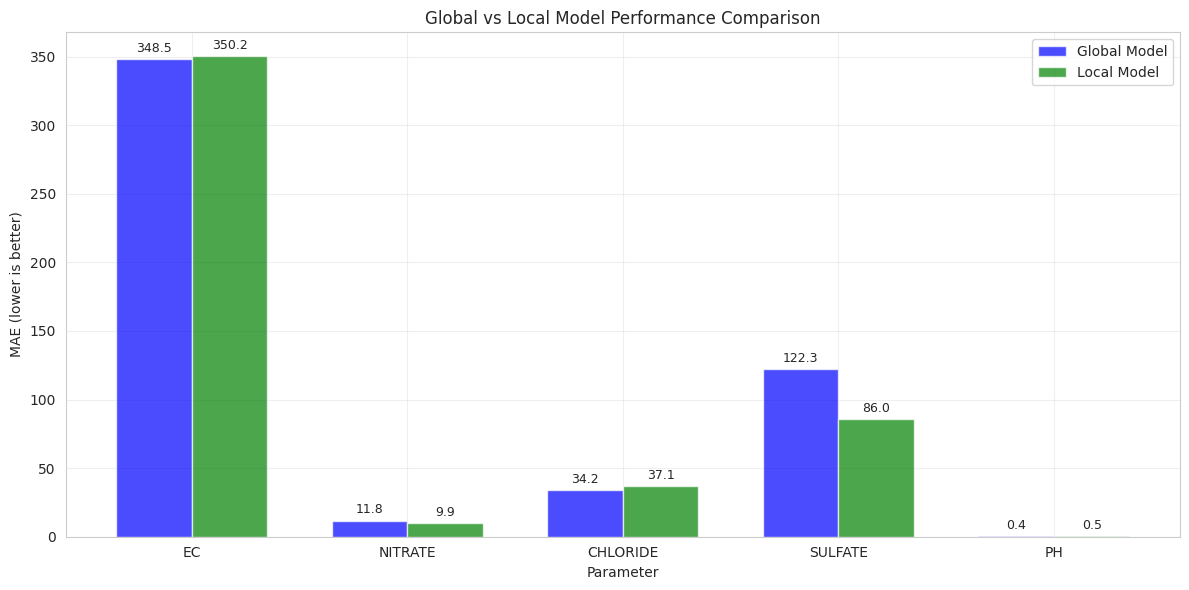

✅ Global_vs_Local.png saved!


In [ ]:
print("=" * 60)
print("📊 VISUALIZING GLOBAL VS LOCAL COMPARISON")
print("=" * 60)

# Bar plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.35

global_values = comparison_df['Global Model (RF) MAE'].values
local_values = comparison_df['Local Model (RF) MAE'].values

bars1 = ax.bar(x - width/2, global_values, width, label='Global Model', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, local_values, width, label='Local Model', color='green', alpha=0.7)

ax.set_xlabel('Parameter')
ax.set_ylabel('MAE (lower is better)')
ax.set_title('Global vs Local Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Parameter'])
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('Global_vs_Local.png', dpi=300)
plt.show()
print("✅ Global_vs_Local.png saved!")

In [ ]:
print("=" * 60)
print("📄 GENERATING PHASE 8 REPORT")
print("=" * 60)

with open('Phase8_Local_Models_Report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("PHASE 8: LOCAL MODELS (PER REGIME) REPORT\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. REGIMES USED FOR LOCAL MODELS\n")
    f.write("-" * 40 + "\n")

    for cluster in sorted(df['Cluster'].dropna().unique()):
        cluster_subset = df[df['Cluster'] == cluster]
        cities = cluster_subset['City'].value_counts()
        f.write(f"\nCluster {cluster}:\n")
        f.write(f"  Size: {len(cluster_subset)} rows\n")
        for city, count in cities.items():
            f.write(f"  {city}: {count} rows\n")

    f.write("\n\n2. LOCAL MODEL PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    if len(local_results_df) > 0:
        f.write(local_results_df.to_string(index=False))
    else:
        f.write("No local models were trained (insufficient data in clusters)\n")

    f.write("\n\n3. GLOBAL VS LOCAL COMPARISON\n")
    f.write("-" * 40 + "\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n\n")

    f.write("4. KEY FINDINGS\n")
    f.write("-" * 40 + "\n")

    for _, row in comparison_df.iterrows():
        param = row['Parameter']
        global_mae = row['Global Model (RF) MAE']
        local_mae = row['Local Model (RF) MAE']
        improvement = row['Improvement (%)']

        if not np.isnan(local_mae):
            if improvement > 0:
                f.write(f"• {param}: Local model improves by {improvement:.1f}% over global\n")
            elif improvement < 0:
                f.write(f"• {param}: Global model performs better than local\n")
            else:
                f.write(f"• {param}: Global and local models perform similarly\n")
        else:
            f.write(f"• {param}: Local model data insufficient for comparison\n")

    f.write("\n\n5. RECOMMENDATION\n")
    f.write("-" * 40 + "\n")

    # Determine best approach
    improvements = comparison_df['Improvement (%)'].dropna()
    if len(improvements) > 0:
        avg_improvement = improvements.mean()
        if avg_improvement > 0:
            f.write(f"Local models show an average improvement of {avg_improvement:.1f}% over global models.\n")
            f.write("RECOMMENDATION: Use LOCAL models for the final product.\n")
        else:
            f.write("Global models perform better or similar to local models.\n")
            f.write("RECOMMENDATION: Use GLOBAL models for the final product.\n")
    else:
        f.write("Insufficient data to make a recommendation.\n")

    f.write("\n\n6. NEXT STEPS\n")
    f.write("-" * 40 + "\n")
    f.write("1. Phase 9: Ensemble Modeling\n")
    f.write("2. Phase 10: Uncertainty Estimation\n")
    f.write("3. Phase 11: WQI Calculation\n")

print("\n✅ Phase8_Local_Models_Report.txt saved!")

📄 GENERATING PHASE 8 REPORT

✅ Phase8_Local_Models_Report.txt saved!
